In [2]:
import torch
import torchvision
import torch.nn as nn
import numpy as np
import os

In [3]:
def check_data(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"# of directories: {len(dirnames)} and {len(filenames)} images in '{dirpath}'.")

In [4]:
from pathlib import Path
data_path = Path("data/")
image_path = data_path / "desert101"

In [5]:
check_data(image_path)

# of directories: 2 and 1 images in 'data\desert101'.
# of directories: 4 and 1 images in 'data\desert101\test'.
# of directories: 0 and 20 images in 'data\desert101\test\baklava'.
# of directories: 0 and 20 images in 'data\desert101\test\cannoli'.
# of directories: 0 and 20 images in 'data\desert101\test\cup_cakes'.
# of directories: 0 and 20 images in 'data\desert101\test\donuts'.
# of directories: 4 and 1 images in 'data\desert101\train'.
# of directories: 0 and 80 images in 'data\desert101\train\baklava'.
# of directories: 0 and 80 images in 'data\desert101\train\cannoli'.
# of directories: 0 and 80 images in 'data\desert101\train\cup_cakes'.
# of directories: 0 and 80 images in 'data\desert101\train\donuts'.


In [6]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [7]:
import random
from PIL import Image 

In [8]:
random.seed(11) 
 
image_path_list = list(image_path.glob("*/*/*.jpg"))
random_image_path = random.choice(image_path_list)  # random image seç
image_class = random_image_path.parent.stem
img = Image.open(random_image_path)

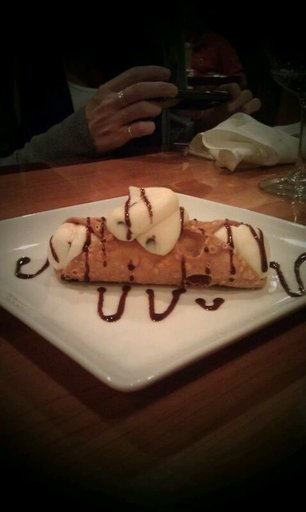

In [9]:
img

In [10]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [11]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.RandomHorizontalFlip(p = 0.3),  # p = probability
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),  # Turn the image into a torch.Tensor
    
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),  # 0.5 mean ve std verdim rastgele (toTensorden sonra gelmeli)
])

In [12]:
train_data = datasets.ImageFolder(root = train_dir, transform = data_transform)
test_data = datasets.ImageFolder(root = test_dir, transform = data_transform)

In [13]:
train_data

Dataset ImageFolder
    Number of datapoints: 316
    Root location: data\desert101\train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.3)
               TrivialAugmentWide(num_magnitude_bins=31, interpolation=InterpolationMode.NEAREST, fill=None)
               ToTensor()
               Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
           )

In [14]:
class_names = train_data.classes

In [15]:
class_names

['baklava', 'cannoli', 'cup_cakes', 'donuts']

In [16]:
len(train_data), len(test_data)

(316, 77)

In [17]:
BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()

train_dataloader = DataLoader(
    dataset = train_data, 
    batch_size = BATCH_SIZE, 
    shuffle = True, 
    num_workers = NUM_WORKERS
)

test_dataloader = DataLoader(
    test_data,
    BATCH_SIZE, 
    shuffle = False, 
    num_workers = NUM_WORKERS
)

In [18]:
train_dataloader

In [19]:
class DesertClassifier(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()
        self.conv_1 = nn.Sequential(
            nn.Conv2d(input_shape, hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )
        
        self.conv_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size = 3, stride = 1, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(hidden_units * 16 * 16,  
                      output_shape)
        )

    def forward(self, x):
        return self.classifier(self.conv_2(self.conv_1(x)))
        

In [20]:
torch.manual_seed(42)
model_0 = DesertClassifier(input_shape=3, # number of color channels (3 for RGB) 
                  hidden_units=32, 
                  output_shape=len(train_data.classes))

In [21]:
! pip install torchinfo

In [22]:
from torchinfo import summary

In [23]:
summary(model_0, input_size = [1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
DesertClassifier                         [1, 4]                    --
├─Sequential: 1-1                        [1, 32, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─ReLU: 2-2                         [1, 32, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 32, 64, 64]           9,248
│    └─ReLU: 2-4                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 32, 32, 32]           --
├─Sequential: 1-2                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-7                         [1, 32, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 32, 32, 32]           9,248
│    └─ReLU: 2-9                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 32, 16, 16]           --
├─Seq

### Test ve Train fonksiyonları

Şimdi train ve test kısımlarını fonksiyon olarak yazacağız.

In [24]:
def train_step(model: torch.nn.Module, dataloader, loss_fn, optimizer):
    
    model.train()
    train_loss = 0
    train_acc = 0

    for batch, (X, y) in enumerate(dataloader):
        # forward 
        y_pred = model(X)

        # calculate loss 
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # accuracy
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim = 1), dim = 1)
        train_acc += (y_pred_class == y).sum().item() / len(y_pred)

    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    
    return train_loss, train_acc

In [25]:
def test_step(model, dataloader, loss_fn):
    
    test_loss = 0
    test_acc = 0
    
    model.eval()
    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            # forward
            test_pred_logits = model(X)

            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            
            test_pred_labels = torch.argmax(torch.softmax(test_pred_logits, dim = 1), dim = 1)
            test_acc += (test_pred_labels == y).sum().item() / len(test_pred_labels)
    
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    
    return test_loss, test_acc   

In [26]:
def train(model, train_dataloader, test_dataloader, optimizer, loss_fn = nn.CrossEntropyLoss(), epochs = 5):
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(epochs):
        train_loss, train_acc = train_step(
            model = model,
            dataloader = train_dataloader,
            optimizer = optimizer,
            loss_fn = loss_fn
        )
        test_loss, test_acc = test_step(
             model = model,
            dataloader = test_dataloader,
            loss_fn = loss_fn
        )

        # Print out what's happening
        print(
            f"Epoch: {epoch + 1} | "
            f"train_loss: {train_loss:.2f} | "
            f"train_acc: {train_acc:.2f} | "
            f"test_loss: {test_loss:.2f} | "
            f"test_acc: {test_acc:.2f}"
        )

        
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)
    
    return results

In [27]:
torch.manual_seed(28)

model_0 = DesertClassifier(input_shape = 3, hidden_units = 32, output_shape = len(train_data.classes))

In [28]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

In [29]:
model_0_results = train(model_0, train_dataloader, test_dataloader, optimizer, loss_fn, epochs = 10)

Epoch: 1 | train_loss: 1.40 | train_acc: 0.22 | test_loss: 1.40 | test_acc: 0.20
Epoch: 2 | train_loss: 1.39 | train_acc: 0.30 | test_loss: 1.39 | test_acc: 0.24
Epoch: 3 | train_loss: 1.38 | train_acc: 0.36 | test_loss: 1.41 | test_acc: 0.17
Epoch: 4 | train_loss: 1.35 | train_acc: 0.37 | test_loss: 1.31 | test_acc: 0.36
Epoch: 5 | train_loss: 1.34 | train_acc: 0.31 | test_loss: 1.37 | test_acc: 0.35
Epoch: 6 | train_loss: 1.29 | train_acc: 0.37 | test_loss: 1.38 | test_acc: 0.30
Epoch: 7 | train_loss: 1.32 | train_acc: 0.36 | test_loss: 1.30 | test_acc: 0.46
Epoch: 8 | train_loss: 1.29 | train_acc: 0.38 | test_loss: 1.31 | test_acc: 0.33
Epoch: 9 | train_loss: 1.27 | train_acc: 0.38 | test_loss: 1.30 | test_acc: 0.37
Epoch: 10 | train_loss: 1.29 | train_acc: 0.39 | test_loss: 1.38 | test_acc: 0.36


In [30]:
model_0_results

{'train_loss': [1.3980328440666199,
  1.3854509353637696,
  1.3758865118026733,
  1.345355713367462,
  1.3394842386245727,
  1.2938464522361754,
  1.3228062987327576,
  1.285613477230072,
  1.271066951751709,
  1.2853912591934205],
 'train_acc': [0.22053571428571428,
  0.30446428571428574,
  0.36026785714285714,
  0.3665178571428572,
  0.31205357142857143,
  0.36741071428571426,
  0.3575892857142857,
  0.3834821428571428,
  0.37901785714285713,
  0.3933035714285714],
 'test_loss': [1.3979932069778442,
  1.3920952876408894,
  1.4071828524271648,
  1.3118492762247722,
  1.3703253269195557,
  1.3756339152654011,
  1.3029279708862305,
  1.306020458539327,
  1.296069582303365,
  1.3841190338134766],
 'test_acc': [0.19791666666666666,
  0.23958333333333334,
  0.16666666666666666,
  0.3573717948717949,
  0.3525641025641026,
  0.3020833333333333,
  0.4599358974358974,
  0.3317307692307692,
  0.3733974358974359,
  0.3581730769230769]}

In [35]:
baklava_path = data_path / "midye-baklava.jpg"
halka_path = data_path / "halka-tatlisi.jpg"

In [36]:
midye_baklava = torchvision.io.read_image(str(baklava_path))
halka_tatlisi = torchvision.io.read_image(str(halka_path))

In [37]:
midye_baklava

tensor([[[231, 231, 231,  ..., 235, 235, 235],
         [231, 231, 231,  ..., 235, 235, 235],
         [231, 231, 231,  ..., 235, 235, 235],
         ...,
         [220, 220, 220,  ..., 220, 220, 220],
         [220, 220, 220,  ..., 220, 220, 220],
         [220, 220, 220,  ..., 220, 220, 220]],

        [[233, 233, 233,  ..., 238, 238, 238],
         [233, 233, 233,  ..., 238, 238, 238],
         [233, 233, 233,  ..., 238, 238, 238],
         ...,
         [227, 227, 227,  ..., 227, 227, 227],
         [227, 227, 227,  ..., 227, 227, 227],
         [227, 227, 227,  ..., 227, 227, 227]],

        [[245, 245, 245,  ..., 245, 245, 245],
         [245, 245, 245,  ..., 245, 245, 245],
         [245, 245, 245,  ..., 245, 245, 245],
         ...,
         [237, 237, 237,  ..., 237, 237, 237],
         [237, 237, 237,  ..., 237, 237, 237],
         [237, 237, 237,  ..., 237, 237, 237]]], dtype=torch.uint8)

In [38]:
midye_baklava = torchvision.io.read_image(str(baklava_path)).type(torch.float32)
halka_tatlisi = torchvision.io.read_image(str(halka_path)).type(torch.float32)

In [39]:
# then convert numbers into [0,1] by dividing it to 255
midye_baklava = midye_baklava / 255
halka_tatlisi = halka_tatlisi / 255

In [40]:
# resize yapmalıyız 
transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
])

# Transform target image
baklava = transform(midye_baklava)
halka = transform(halka_tatlisi)

In [41]:
baklava.shape

torch.Size([3, 64, 64])

In [42]:
baklava.unsqueeze(dim=0).shape

torch.Size([1, 3, 64, 64])

In [43]:
baklava = baklava.unsqueeze(dim=0)
halka = halka.unsqueeze(dim=0)

In [46]:
# beklenen  ->  baklava
model_0.eval()
with torch.inference_mode():
    logits = model_0(baklava)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(dim=1).item()

print("Predicted class:", class_names[pred_idx])

Predicted class: cannoli


In [48]:
# halka tatlısı ile eğitmedik. 
model_0.eval()
with torch.inference_mode():
    logits = model_0(halka)
    probs = torch.softmax(logits, dim=1)
    pred_idx = probs.argmax(dim=1).item()

print("Predicted class:", class_names[pred_idx])

Predicted class: cannoli


In [50]:
from sklearn.metrics import confusion_matrix

# 1. Tahminleri Topla
device = "cuda" if torch.cuda.is_available() else "cpu"

y_preds = []
y_true = []

model_0.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        y_logit = model_0(X)
        y_pred = torch.softmax(y_logit, dim=1).argmax(dim=1)
        y_preds.extend(y_pred.cpu().numpy())
        y_true.extend(y.cpu().numpy())

# 2. Karşılaştırma ve Sonuçlar
cm = confusion_matrix(y_true, y_preds)
class_names = test_data.classes

print(f"{'Sınıf Adı':<15} | {'Doğru Tahmin':<15} | {'Toplam':<10} | {'Başarı (%)'}")
print("-" * 55)

for i, class_name in enumerate(class_names):
    correct = cm[i, i]
    total = cm[i].sum()
    accuracy = (correct / total) * 100 if total > 0 else 0
    print(f"{class_name:<15} | {correct:<15} | {total:<10} | %{accuracy:.2f}")

print("-" * 55)
print(f"Genel Doğruluk: %{(sum(cm.diagonal())/len(y_true))*100:.2f}")

Sınıf Adı       | Doğru Tahmin    | Toplam     | Başarı (%)
-------------------------------------------------------
baklava         | 5               | 19         | %26.32
cannoli         | 10              | 19         | %52.63
cup_cakes       | 10              | 20         | %50.00
donuts          | 3               | 19         | %15.79
-------------------------------------------------------
Genel Doğruluk: %36.36
